In [94]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import seaborn as sns
import matplotlib.pyplot as plt

import joblib
import os

In [95]:
url = "https://raw.githubusercontent.com/tirtho2002/Assignment-6-KMeans/main/dataset/customers.csv"

df = pd.read_csv(url)


In [96]:
df.head()


,id,name,segment,state,city
0,CG-12520,Claire Gute,Consumer,Kentucky,Henderson
1,DV-13045,Darrin Van Huff,Corporate,California,Los Angeles
2,SO-20335,Sean O'Donnell,Consumer,Florida,Fort Lauderdale
3,BH-11710,Brosina Hoffman,Consumer,California,Los Angeles
4,AA-10480,Andrew Allen,Consumer,North Carolina,Concord


In [97]:
!git clone https://github.com/tirtho2002/Assignment-6-KMeans.git

Cloning into 'Assignment-6-KMeans'...
remote: Enumerating objects: 9, done.
remote: Counting objects: 100% (9/9), done.
remote: Compressing objects: 100% (5/5), done.
remote: Total 9 (delta 0), reused 6 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (9/9), 15.07 KiB | 15.07 MiB/s, done.


In [98]:
%cd Assignment-6-KMeans


/content/Assignment-6-KMeans/Assignment-6-KMeans/Assignment-6-KMeans/Assignment-6-KMeans


In [99]:
!git pull origin main

From https://github.com/tirtho2002/Assignment-6-KMeans
 * branch            main       -> FETCH_HEAD
Already up to date.


In [100]:
custom_df = pd.read_csv(
    "/content/Assignment-6-KMeans/dataset/customers.csv"
)
custom_df.head()

,id,name,segment,state,city
0,CG-12520,Claire Gute,Consumer,Kentucky,Henderson
1,DV-13045,Darrin Van Huff,Corporate,California,Los Angeles
2,SO-20335,Sean O'Donnell,Consumer,Florida,Fort Lauderdale
3,BH-11710,Brosina Hoffman,Consumer,California,Los Angeles
4,AA-10480,Andrew Allen,Consumer,North Carolina,Concord


In [101]:
# Dataset Exploration

# 1.Shape of Dataset
print("Shape of Dataset:")
print(df.shape)

# 2.Display 5 Random Samples
print("5 Random Samples:")
print(df.sample(5))

# 3.Dataset Information
print("Dataset Info:")
df.info()

# 4.Statistical Summary
print("Statistical Summary:")
print(df.describe())

# 5.Number of unique values in each column.
print("Number of Unique Values in Each Column:")
print(df.nunique())

# 6.Check Missing Values
print("Missing Values:")
print(df.isnull().sum())

# 7.Check Duplicate Rows
print("Duplicate Rows:")
print(df.duplicated().sum())

# 8.Memory Usage
print("Memory Usage:")
print(df.memory_usage())

# 9.Check Skewness
print("Skewness:")
print(df.skew(numeric_only=True))

Shape of Dataset:
(793, 5)
5 Random Samples:
           id                name      segment       state          city
276  RS-19765      Roland Schwarz    Corporate    New York  Mount Vernon
244  CA-12265  Christina Anderson     Consumer    Illinois       Chicago
218  GT-14710           Greg Tran     Consumer       Texas       Houston
646  TC-21295       Toby Carlisle     Consumer  California     San Diego
503  DP-13390       Dennis Pardue  Home Office    Illinois        Peoria
Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 793 entries, 0 to 792
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   id       793 non-null    object
 1   name     793 non-null    object
 2   segment  793 non-null    object
 3   state    793 non-null    object
 4   city     793 non-null    object
dtypes: object(5)
memory usage: 31.1+ KB
Statistical Summary:
              id               name   segment       state           city
count

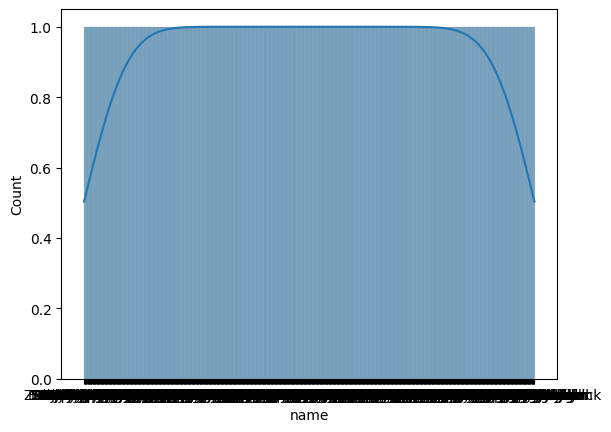

In [102]:
sns.histplot(df["name"], kde=True)
plt.show()

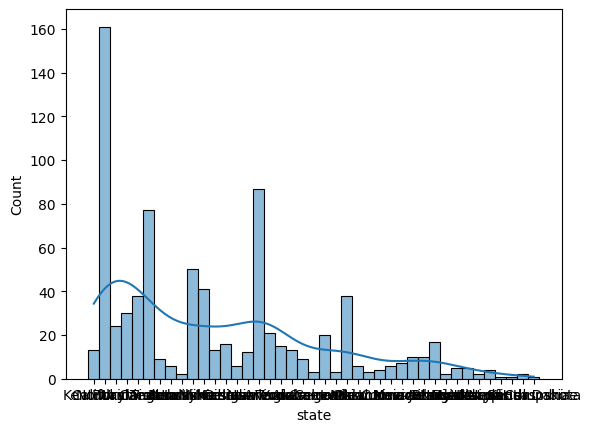

In [103]:
sns.histplot(df["state"], kde=True)
plt.show()

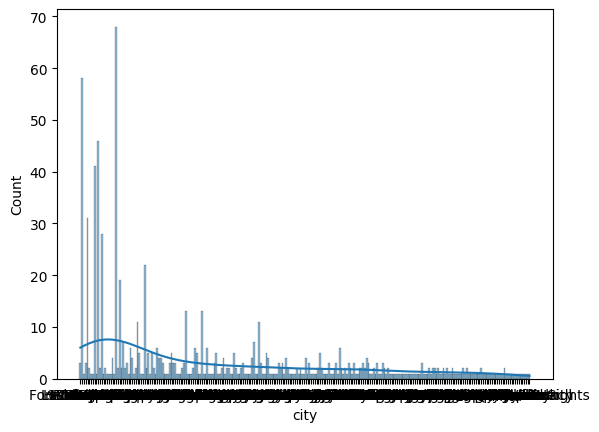

In [104]:
sns.histplot(df["city"], kde=True)
plt.show()

In [105]:
from sklearn.preprocessing import LabelEncoder

df_encoded = df.copy()

le = LabelEncoder()
df_encoded["state"] = le.fit_transform(df_encoded["state"])
df_encoded["city"] = le.fit_transform(df_encoded["city"])
df_encoded["segment"] = le.fit_transform(df_encoded["segment"])



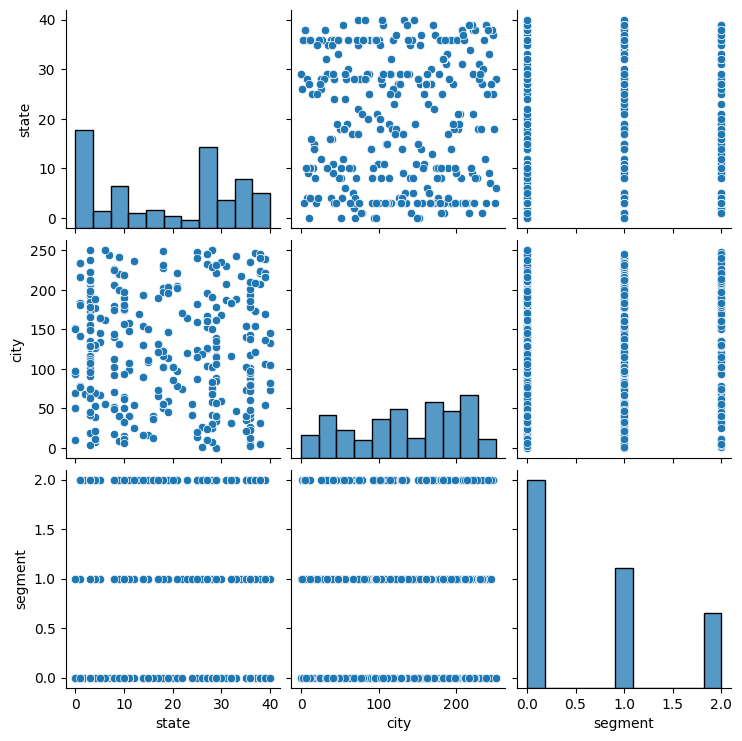

In [106]:
sns.pairplot(df_encoded[["state", "city", "segment"]])

In [107]:
from sklearn.preprocessing import LabelEncoder

df_encoded = df.copy()

le = LabelEncoder()
df_encoded["state"] = le.fit_transform(df_encoded["state"])
df_encoded["city"] = le.fit_transform(df_encoded["city"])
df_encoded["segment"] = le.fit_transform(df_encoded["segment"])

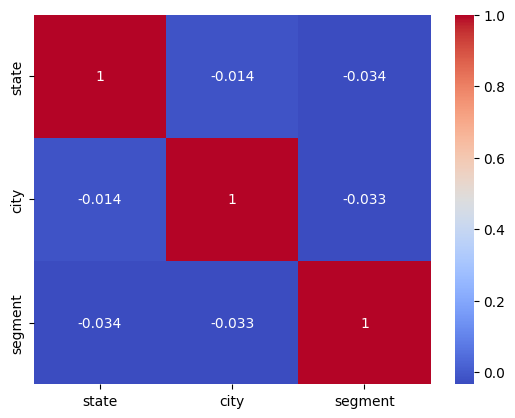

In [108]:
import seaborn as sns
import matplotlib.pyplot as plt

corr = df_encoded[["state", "city", "segment"]].corr()

sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.show()

In [109]:
X = df[["segment", "state", "city"]]

In [110]:
from sklearn.preprocessing import LabelEncoder, StandardScaler

df_encoded = df.copy()

for col in ["segment", "state", "city"]:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df_encoded[col])

X = df_encoded[["segment", "state", "city"]]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [111]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

wcss = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

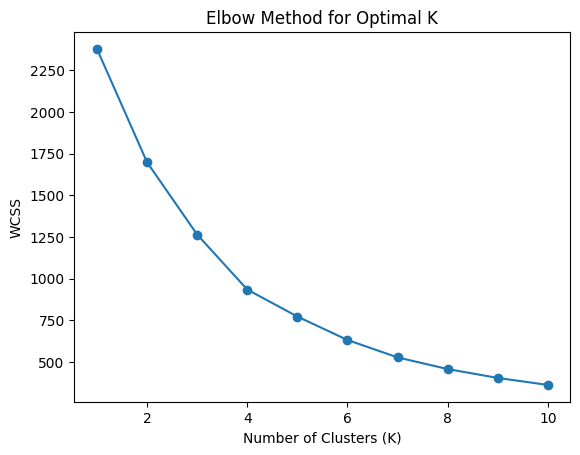

In [112]:
plt.plot(range(1, 11), wcss, marker='o')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS")
plt.title("Elbow Method for Optimal K")
plt.show()

In [113]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
kmeans.fit(X_scaled)

KMeans(n_clusters=3, n_init=10, random_state=42)

In [114]:
import joblib

joblib.dump(kmeans, "kmeans_model.pkl")
from google.colab import files
files.download("kmeans_model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [115]:
import pickle

with open("kmeans_model.pkl", "wb") as f:
    pickle.dump(kmeans, f)


In [116]:
model = joblib.load("kmeans_model.pkl")

In [117]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

In [118]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df["cluster"] = kmeans.fit_predict(X_scaled)

In [123]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

df["PCA1"] = X_pca[:, 0]
df["PCA2"] = X_pca[:, 1]
df[["PCA1", "PCA2"]].head()

,PCA1,PCA2
0,-0.178561,-0.164243
1,0.942967,0.797012
2,0.159367,-0.057567
3,-0.039334,0.815031
4,-0.366405,-1.393222


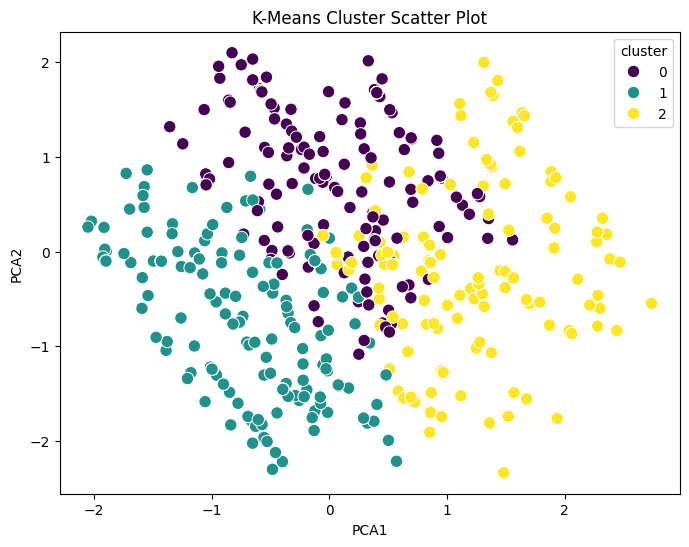

In [124]:


plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x="PCA1",
    y="PCA2",
    hue="cluster",
    palette="viridis",
    s=80
)

plt.title("K-Means Cluster Scatter Plot")
plt.show()

In [125]:
joblib.dump(kmeans, "kmeans_model.pkl")

['kmeans_model.pkl']

In [126]:
from google.colab import files
files.download("kmeans_model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>